In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------
# 1. CONFIG
# -----------------------

n = 5000

zones = ['Suba', 'Chapinero', 'Engativa', 'Los Martires', 'Usaquen', 'Fontibon']

zone_probs = [0.22, 0.15, 0.18, 0.15, 0.15, 0.15]

# -----------------------
# 2. LIMITES GEOGRÁFICOS (bounding box)
# -----------------------

zone_bounds = {
    'Suba': {
        'lat_min': 4.70, 'lat_max': 4.78,
        'lon_min': -74.12, 'lon_max': -74.05
    },
    'Chapinero': {
        'lat_min': 4.63, 'lat_max': 4.69,
        'lon_min': -74.08, 'lon_max': -74.02
    },
    'Engativa': {
        'lat_min': 4.67, 'lat_max': 4.73,
        'lon_min': -74.14, 'lon_max': -74.09
    },
    'Los Martires': {
        'lat_min': 4.59, 'lat_max': 4.63,
        'lon_min': -74.11, 'lon_max': -74.07
    },
    'Usaquen': {
    'lat_min': 4.69, 'lat_max': 4.75,
    'lon_min': -74.07, 'lon_max': -74.01
    },
    'Fontibon': {
        'lat_min': 4.65, 'lat_max': 4.71,
        'lon_min': -74.15, 'lon_max': -74.10
    }
}

# -----------------------
# 3. BASE DATAFRAME
# -----------------------

df = pd.DataFrame({
    'id': range(51801, 51801 + n),
    'zone': np.random.choice(zones, n, p=zone_probs),
    'timestamp': pd.date_range('2025-01-01', periods=n, freq='30s')
})

# -----------------------
# 4. GRID NAME
# -----------------------

def assign_grid(zone):
    return f'{zone}_Grid_{np.random.randint(1,20)}'

df['gridName'] = df['zone'].apply(assign_grid)

# -----------------------
# 5. COORDENADAS REALISTAS (FINAL PRO)
# -----------------------

def generate_coordinates(zone):
    bounds = zone_bounds[zone]
    
    for _ in range(15):  # más intentos = menos probabilidad de fallback
        
        # distribución tipo ciudad (cluster suave)
        center_lat = (bounds['lat_min'] + bounds['lat_max']) / 2
        center_lon = (bounds['lon_min'] + bounds['lon_max']) / 2
        
        lat = np.random.normal(center_lat, 0.012)
        lon = np.random.normal(center_lon, 0.012)
        
        # limitar al bounding box
        lat = np.clip(lat, bounds['lat_min'], bounds['lat_max'])
        lon = np.clip(lon, bounds['lon_min'], bounds['lon_max'])
        
        # 🔥 FILTRO CERROS (rechazo inteligente)
        if zone == 'Chapinero' and lon > -74.054:
            continue
            
        if zone == 'Usaquen' and lon > -74.027:
            continue
        
        # si pasa el filtro → se acepta
        return lat, lon
    
    # ⚠️ fallback (muy raro que pase)
    return center_lat, center_lon


# aplicar al dataframe
coords = df['zone'].apply(generate_coordinates)

df['latitude'] = coords.apply(lambda x: x[0])
df['longitude'] = coords.apply(lambda x: x[1])

# -----------------------
# 6. RADIO DEL DSA
# -----------------------

def assign_radius():
    r = np.random.rand()
    if r < 0.75:
        return 50
    elif r < 0.85:
        return 40
    elif r < 0.93:
        return 30
    elif r < 0.98:
        return 20
    else:
        return 10

df['dsaRadius'] = [assign_radius() for _ in range(n)]

# -----------------------
# 7. NUMERO DE FUGAS (70% con fuga)
# -----------------------

def assign_leaks():
    r = np.random.rand()
    
    if r < 0.30:
        return 0
    elif r < 0.75:
        return 1
    elif r < 0.93:
        return 2
    else:
        return 3

df['nLeaks'] = [assign_leaks() for _ in range(n)]

# -----------------------
# 8. VARIABLES BASE
# -----------------------

df['backgroundCh4'] = np.random.uniform(1.8, 2.1, n)

# -----------------------
# 9. VARIABLES DEPENDIENTES (MEJORADO)
# -----------------------

def simulate_row(row):
    leaks = row['nLeaks']
    
    if leaks == 0:
        max_ch4 = np.random.uniform(1.8, 2.4)
        detection = np.random.randint(1, 3)
        corr = np.random.uniform(0.3, 0.7)
        flow = np.random.uniform(0, 5)
    
    else:
        # 🔹 base normal
        base = np.random.uniform(2.5, 6 + leaks)
        
        # 🔥 probabilidad de eventos tipo AMLD
        spike_prob = np.random.rand()
        
        if spike_prob < 0.02:
            # 🔥 eventos extremos (muy raros)
            max_ch4 = base + np.random.uniform(25, 80)
        elif spike_prob < 0.12:
            # 🔥 picos altos (ocasionales)
            max_ch4 = base + np.random.uniform(5, 25)
        else:
            # 🔹 comportamiento normal
            max_ch4 = base
        
        # 🔹 detecciones
        detection = np.random.randint(3, 8 + leaks)
        
        # 🔹 correlación alta en fugas reales
        corr = np.random.uniform(0.85, 1.0)
        
        # 🔹 flujo base
        flow = np.random.uniform(5, 120 * leaks)
        
        # 🔥 RELACIÓN CONCENTRACIÓN ↔ FLUJO (clave)
        if max_ch4 > 20:
            flow *= np.random.uniform(1.5, 3)
        elif max_ch4 > 10:
            flow *= np.random.uniform(1.2, 1.8)
    
    return pd.Series([max_ch4, detection, corr, flow])


df[['maxCh4', 'detectionCount', 'correlation', 'estFlowRateInScfh']] = df.apply(simulate_row, axis=1)

# -----------------------
# 10. CONFIDENCE CORREGIDO
# -----------------------

def calculate_confidence(correlation, detection_count, flow):
    score = (
        (correlation * 2.5) +
        (min(detection_count, 10) * 0.6) +
        (min(flow, 100) * 0.02)
    )
    return min(score, 5)

df['confidence'] = df.apply(
    lambda row: calculate_confidence(
        row['correlation'],
        row['detectionCount'],
        row['estFlowRateInScfh']
    ),
    axis=1
)

# -----------------------
# 11. REAL LEAK
# -----------------------

df['realLeak'] = df['nLeaks'].apply(lambda x: 1 if x > 0 else 0)

# -----------------------
# 12. INVESTIGATE STATUS
# -----------------------

def assign_investigate_status(row):
    if row['confidence'] >= 4.5 and row['detectionCount'] >= 5:
        return 'ConfirmedLeak'
    elif row['confidence'] >= 3.5:
        return 'LikelyLeak'
    elif row['confidence'] >= 2.5:
        return 'PossibleLeak'
    else:
        return 'NoLeak'

df['investigateStatus'] = df.apply(assign_investigate_status, axis=1)

# -----------------------
# 13. METADATA
# -----------------------

df['status'] = 'NoInvestigated'
df['surveyId'] = np.random.randint(1000, 2000, n)
df['discoveredDate'] = df['timestamp']
df['lastUpdatedAt'] = df['timestamp']

df['lastUpdatedBy'] = np.random.choice(
    [
        'andres.perez@searchleaks.com',
        'carolina.martinez@searchleaks.com',
        'manuel.rodriguez@searchleaks.com'
    ],
    n
)

# -----------------------
# 13. VARIABLES DERIVADAS (FIX ERROR)
# -----------------------

df['ch4Delta'] = df['maxCh4'] - df['backgroundCh4']

df['estFlowRateInGh'] = df['estFlowRateInScfh'] * 0.0192

df['c2h6Ch4Ratio'] = np.random.uniform(0.01, 0.08, len(df))

# -----------------------
# 14. EXPORT
# -----------------------

df_export = df[[
    'id', 'status', 'investigateStatus', 'discoveredDate',
    'estFlowRateInScfh', 'estFlowRateInGh', 'maxCh4',
    'correlation', 'confidence', 'detectionCount',
    'ch4Delta', 'latitude', 'longitude', 'c2h6Ch4Ratio',
    'backgroundCh4', 'gridName', 'surveyId',
    'lastUpdatedBy', 'lastUpdatedAt',
    'dsaRadius', 'nLeaks', 'realLeak'
]]

df_export.to_csv('../00_data/00_raw/methane_leak_dataset_realistic.csv', index=False)
df_export.to_excel('../00_data/00_raw/methane_leak_dataset_realistic.xlsx',
                  index=False, sheet_name='Simulacion_Metano')

In [18]:
df_export['investigateStatus'].value_counts()

investigateStatus
ConfirmedLeak    2366
NoLeak           1122
LikelyLeak       1100
PossibleLeak      412
Name: count, dtype: int64

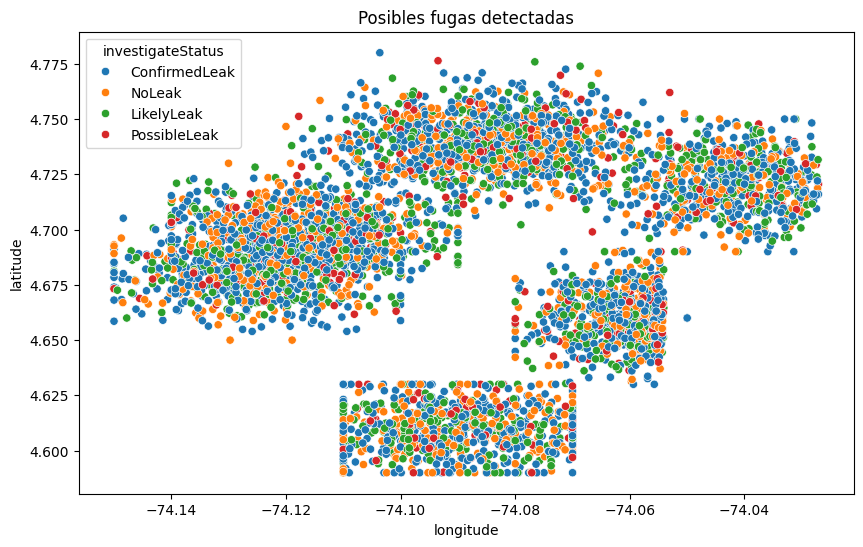

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='longitude', y='latitude', hue='investigateStatus')

plt.title('Posibles fugas detectadas')
plt.show()

In [ ]:
import folium

# centro aproximado Bogotá
mapa = folium.Map(location=[4.68, -74.08], zoom_start=12)

for _, row in df_export.sample(1000).iterrows():  # sample para no saturar
    
    folium.Circle(
        location=[row['latitude'], row['longitude']],
        radius=row['dsaRadius'],  # 👈 en metros (REAL)
        color=None,
        fill=True,
        fill_opacity=0.4
    ).add_to(mapa)

mapa